In [2]:
%pwd

'd:\\AIML_Projects\\Global-Mobility-Application\\notebook'

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("EasyVisa.csv")

In [3]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [7]:
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [8]:
data.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [6]:
list(data.columns)

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'no_of_employees',
 'yr_of_estab',
 'region_of_employment',
 'prevailing_wage',
 'unit_of_wage',
 'full_time_position',
 'case_status']

 # Extracting numerical and categorical columns separately 

In [10]:
data.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [11]:
numerical_features = [column for column in data.columns if data[column].dtype!='O' ]
categorical_features = [column for column in data.columns if data[column].dtype=='O' ]

In [12]:
numerical_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [13]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [14]:
categorical_features.remove('case_id')

In [15]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [16]:
for column in categorical_features:

    print(data[column].value_counts(normalize=True)*100)
    print("--------")
    print()

continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
--------

education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
--------

has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
--------

requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
--------

region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
--------

unit_of_wage
Year     90.117739
Hour      8.465463
Week      1.067504
Month     0.349294
Name: proportion, dtype: float64
--------

full_time_position
Y    89.375981
N    10.624019
Name: proportion, dtype: float64
--------

case_status
Certified    66.78

# univariant analysis 

In [17]:
# numeric features
import seaborn as sns

In [18]:
numerical_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

<Axes: xlabel='no_of_employees', ylabel='Count'>

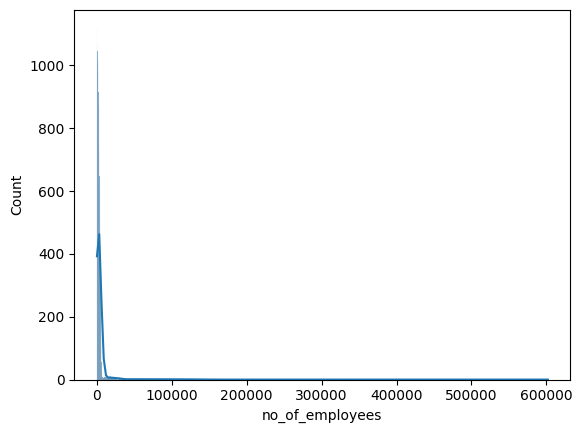

In [19]:
sns.histplot(data["no_of_employees"],kde=True)

<Axes: xlabel='prevailing_wage', ylabel='Count'>

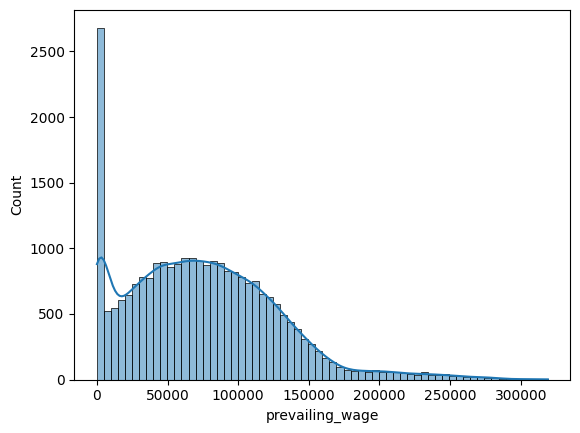

In [20]:
sns.histplot(data["prevailing_wage"],kde=True)

<Axes: xlabel='yr_of_estab', ylabel='Count'>

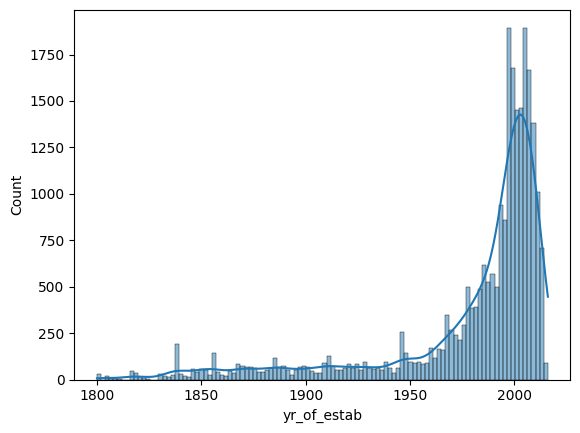

In [21]:
sns.histplot(data["yr_of_estab"],kde=True)

<Axes: xlabel='no_of_employees'>

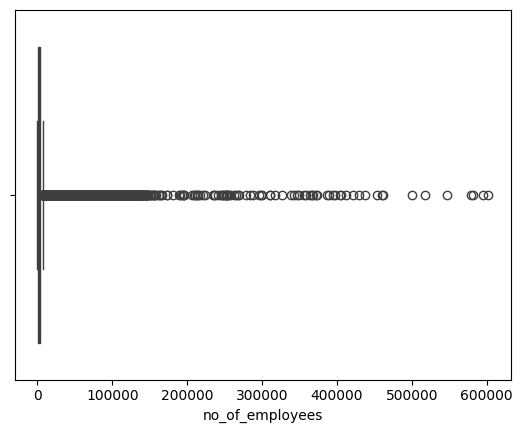

In [22]:
sns.boxplot(x=data["no_of_employees"])

<Axes: xlabel='prevailing_wage'>

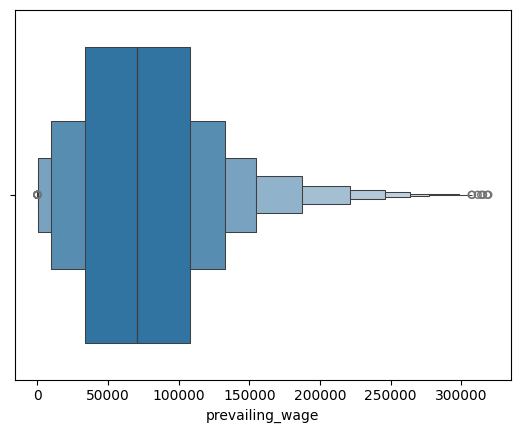

In [23]:
sns.boxenplot(x=data["prevailing_wage"])

<Axes: xlabel='yr_of_estab'>

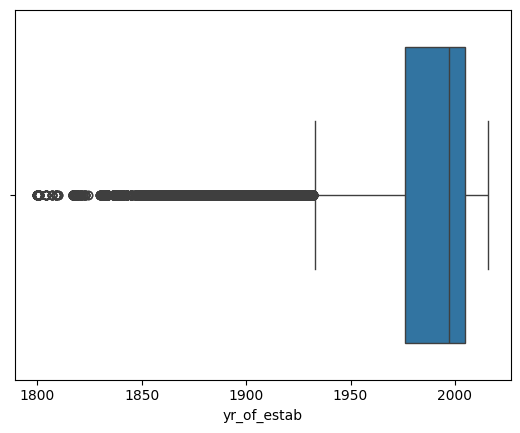

In [24]:
sns.boxplot(x=data["yr_of_estab"])

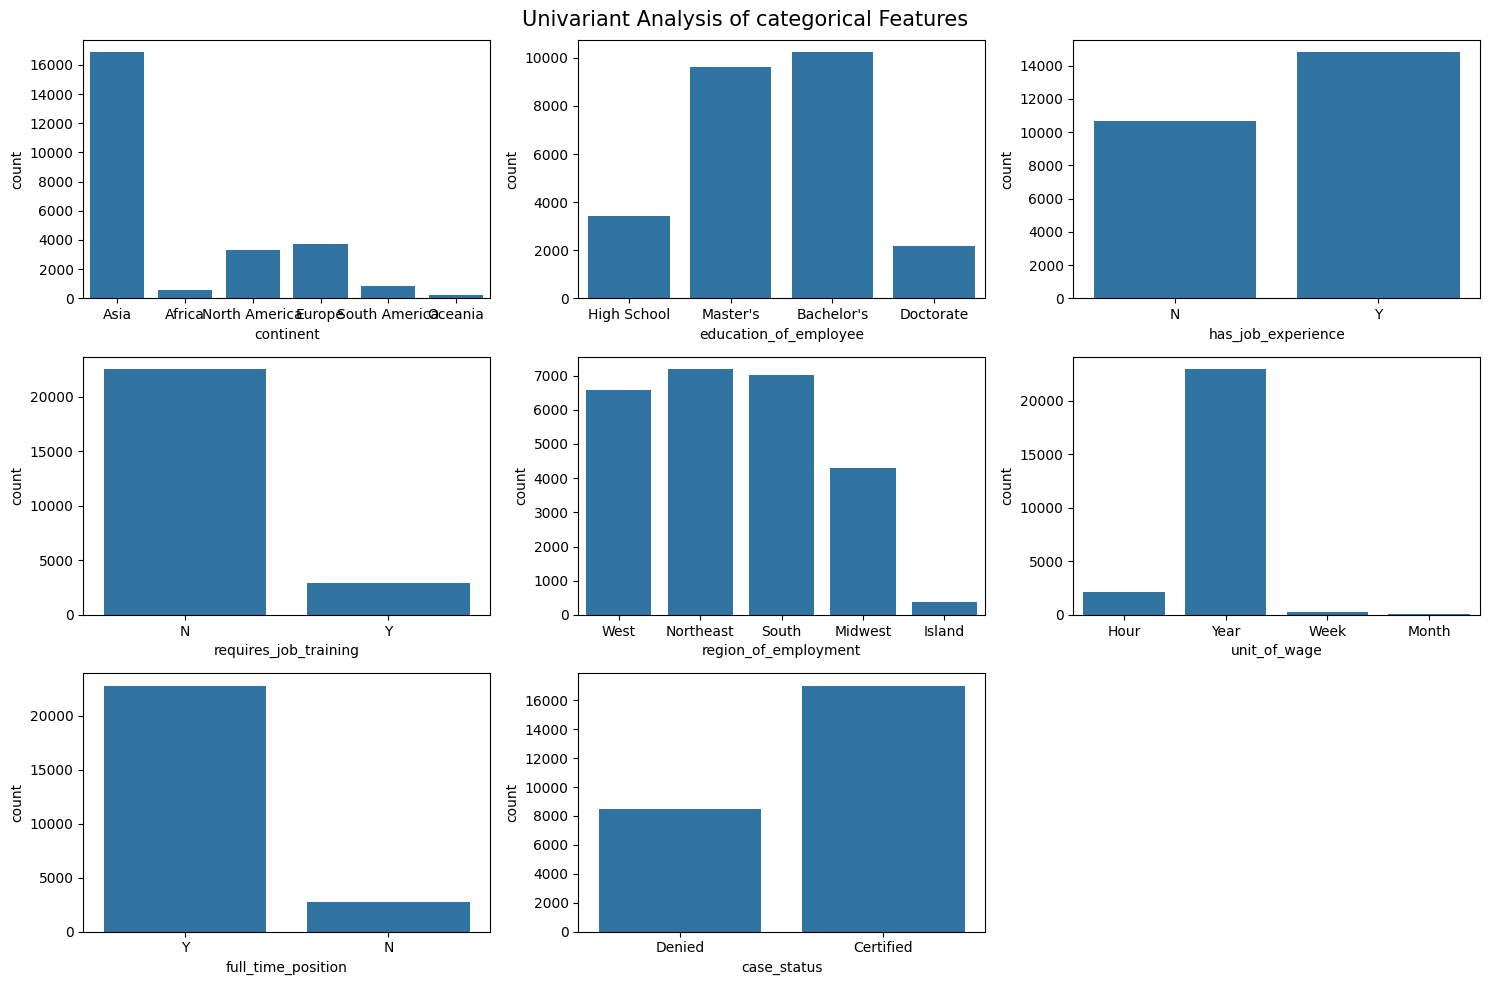

In [25]:
# categorical features
from matplotlib import pyplot as plt
plt.figure(figsize=(15,10))
plt.suptitle("Univariant Analysis of categorical Features",fontsize= 15)

for i in range(0, len(categorical_features)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=data[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

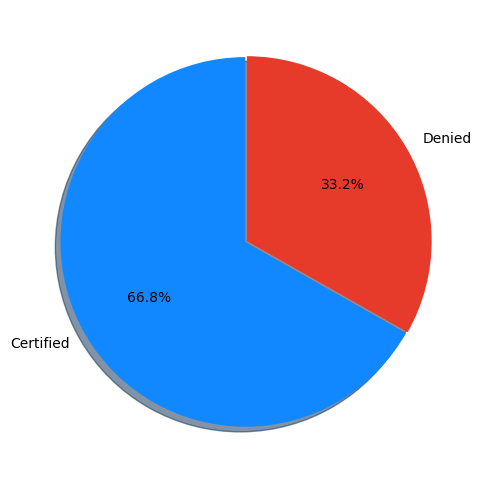

In [26]:
#visualizing target future 

percentage = data.case_status.value_counts(normalize=True)*100

labels=["Certified","Denied"]

explode = [0.01,0]
plt.figure(figsize=(15,6))
colors = ["#1188ff","#e63a2a"]
plt.pie(percentage,autopct='%1.1f%%',labels=labels,startangle=90,shadow=True,colors=colors,explode=explode)
plt.show()

In [27]:
data.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

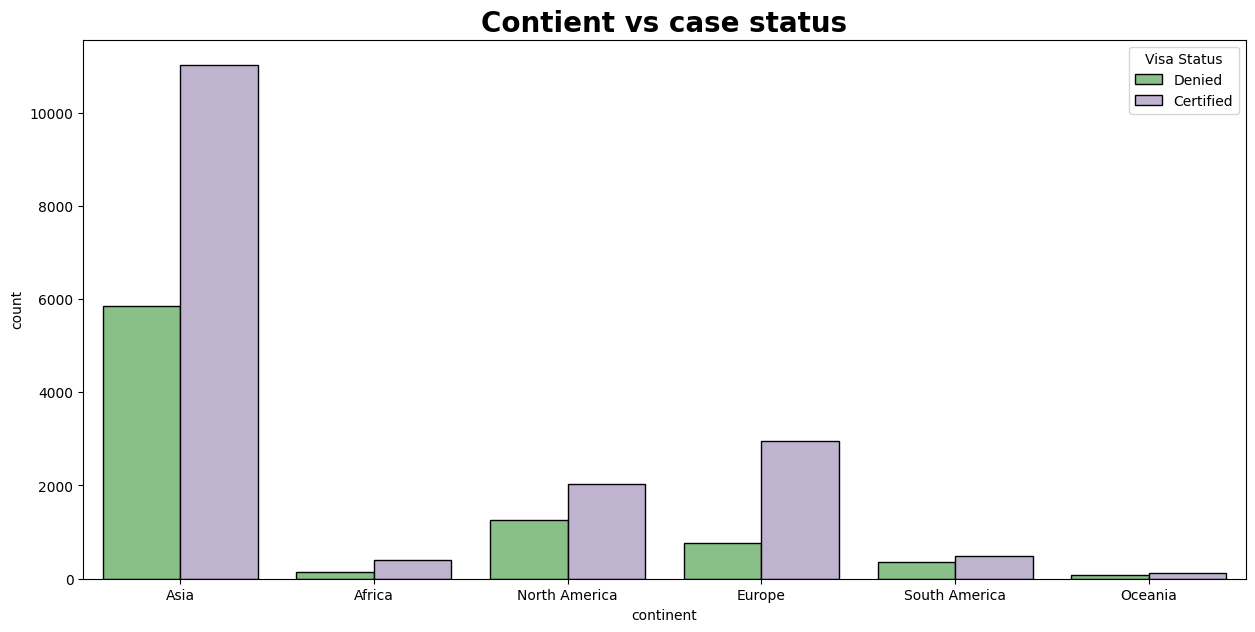

In [28]:
plt.figure(figsize=(15,7))
sns.countplot(x="continent",hue="case_status",data=data,ec="black",palette = "Accent")
plt.title("Contient vs case status",weight="bold",fontsize = 20)
plt.ylabel("count")
plt.xlabel("continent")
plt.legend(title  = "Visa Status",fancybox = True)
plt.show()

In [29]:
# education_of_employee

data.groupby("education_of_employee")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

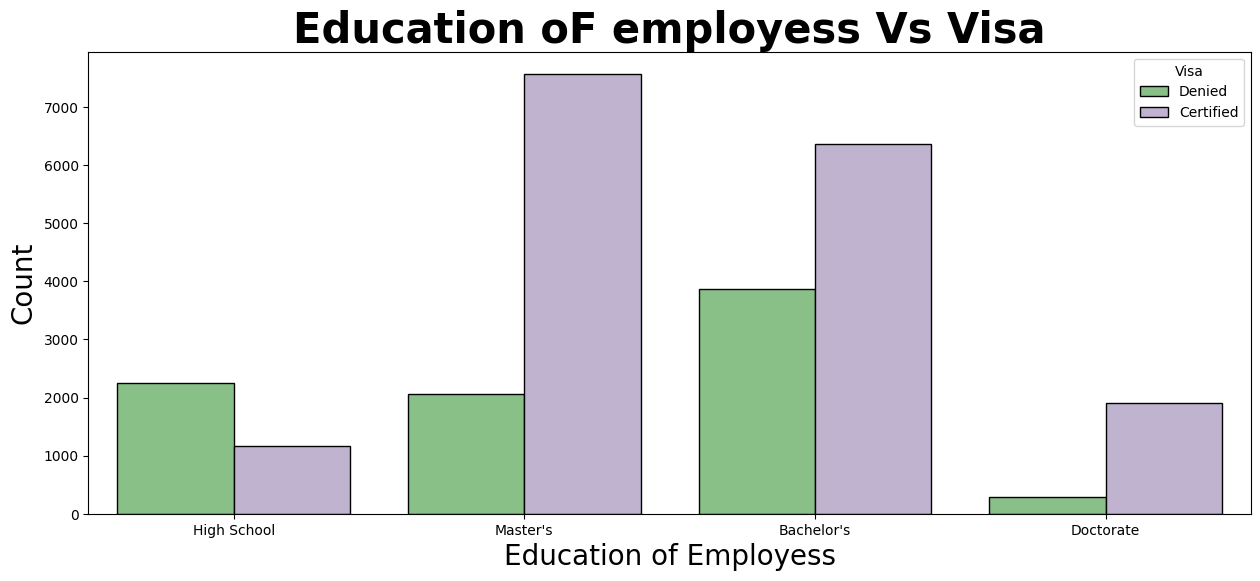

In [30]:
plt.figure(figsize=(15,6))
sns.countplot(x="education_of_employee",hue = "case_status",ec ="black",palette= "Accent",data=data)
plt.title("Education oF employess Vs Visa",weight = "bold",fontsize=30)
plt.xlabel("Education of Employess",fontsize =  20)
plt.ylabel("Count",fontsize = 20)
plt.legend(title = "Visa",fancybox = True)
plt.show()

In [31]:
# 'has_job_experience'
data.groupby("has_job_experience")["case_status"].value_counts(normalize=True).to_frame()*100


proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

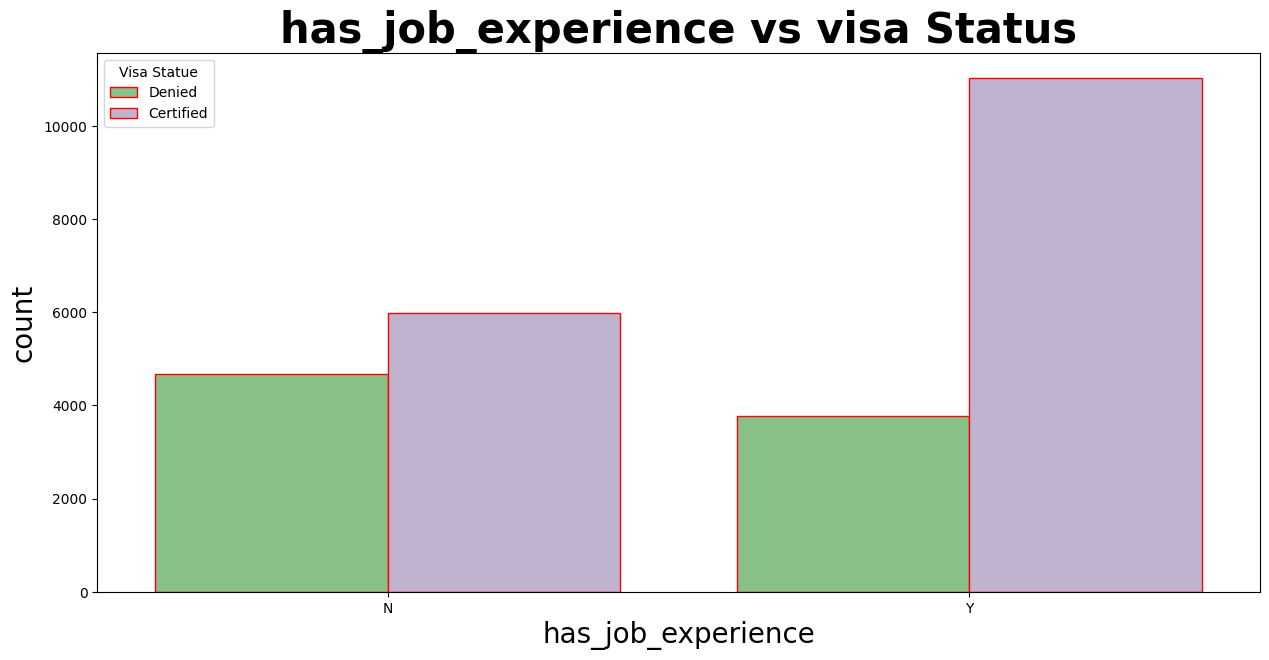

In [32]:
plt.figure(figsize=(15,7))
sns.countplot(x='has_job_experience',hue="case_status",palette="Accent",data=data,ec="red")
plt.title("has_job_experience vs visa Status",weight="bold",fontsize=30)
plt.xlabel("has_job_experience",fontsize=20)
plt.ylabel("count",fontsize = 20)
plt.legend(title = "Visa Statue",fancybox=True)
plt.show()

In [33]:
# requires_job_training
data.groupby("requires_job_training")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

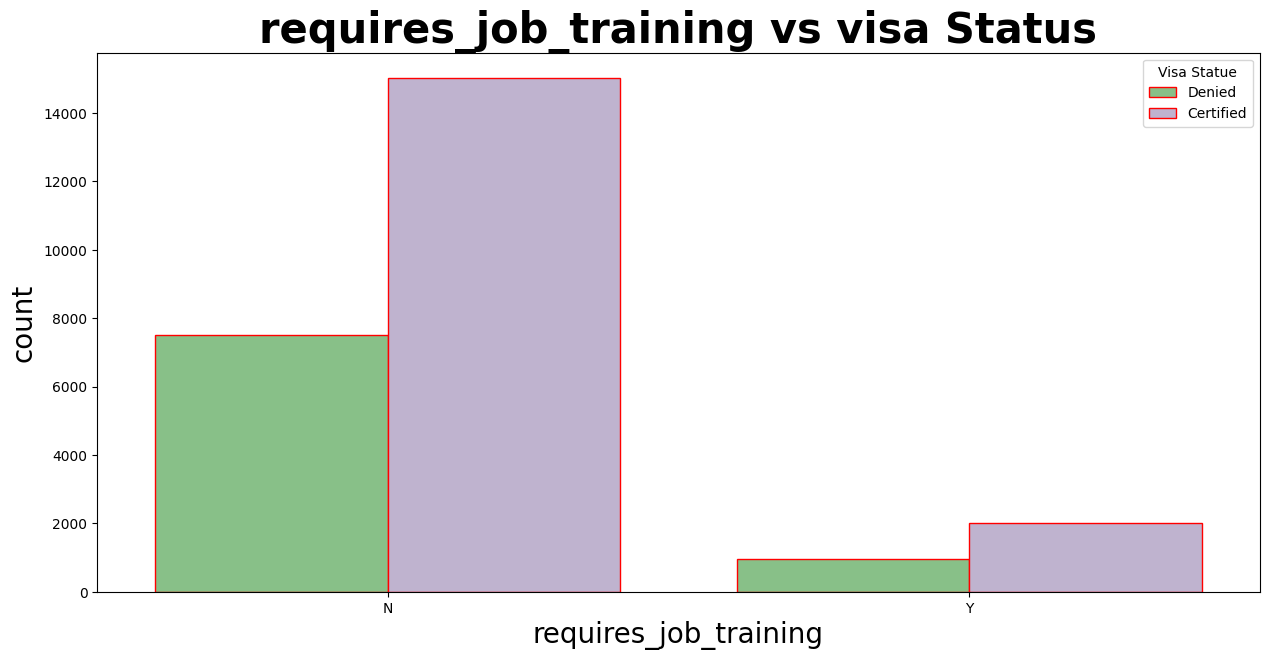

In [34]:
plt.figure(figsize=(15,7))
sns.countplot(x='requires_job_training',hue="case_status",palette="Accent",data=data,ec="red")
plt.title("requires_job_training vs visa Status",weight="bold",fontsize=30)
plt.xlabel("requires_job_training",fontsize=20)
plt.ylabel("count",fontsize = 20)
plt.legend(title = "Visa Statue",fancybox=True)
plt.show()

In [35]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [36]:
# region_of_employment
data.groupby("region_of_employment")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
region_of_employment case_status            
Island               Certified     60.266667
                     Denied        39.733333
Midwest              Certified     75.528210
                     Denied        24.471790
Northeast            Certified     62.904795
                     Denied        37.095205
South                Certified     70.015676
                     Denied        29.984324
West                 Certified     62.253265
                     Denied        37.746735

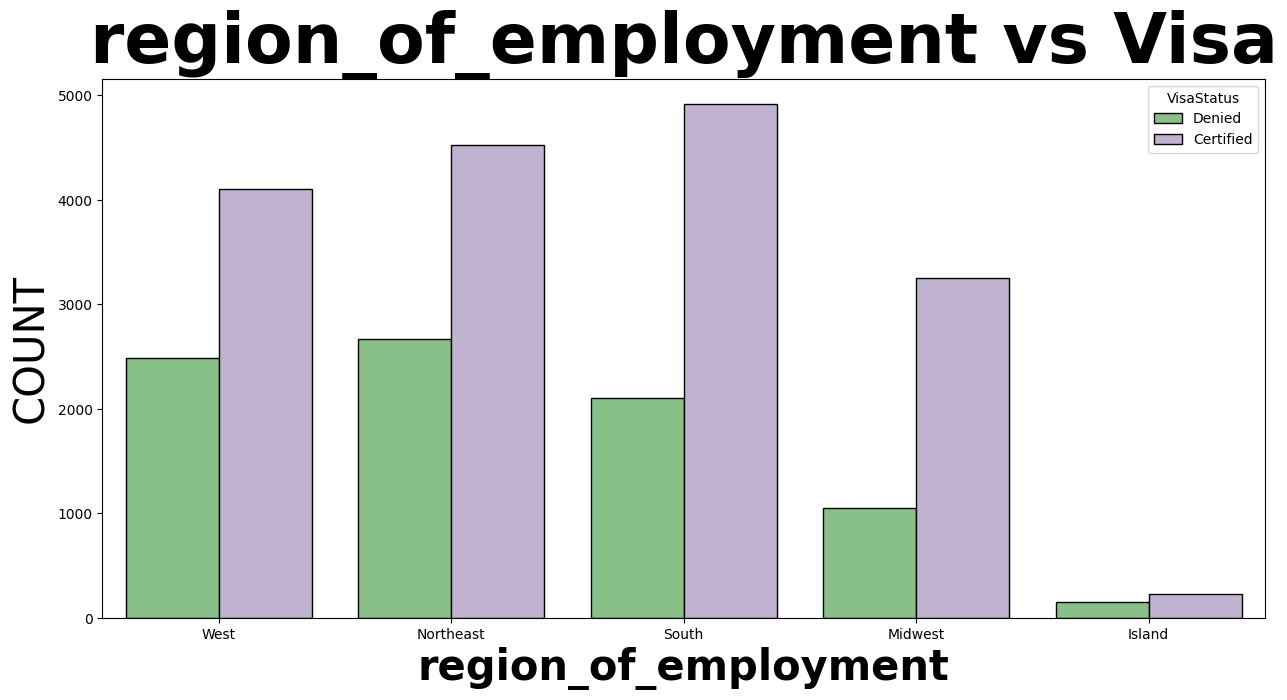

In [37]:
plt.figure(figsize=(15,7))
sns.countplot(x="region_of_employment",hue="case_status",ec="black",data=data,palette="Accent")
plt.title("region_of_employment vs Visa",weight="bold",fontsize=50)
plt.xlabel("region_of_employment",weight="bold",fontsize=30)
plt.ylabel("COUNT",fontsize=30)
plt.legend(title="VisaStatus",fancybox=True)
plt.show()

In [38]:
# unit_of_wage
data.groupby("unit_of_wage")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
unit_of_wage case_status            
Hour         Denied        65.368567
             Certified     34.631433
Month        Certified     61.797753
             Denied        38.202247
Week         Certified     62.132353
             Denied        37.867647
Year         Certified     69.885027
             Denied        30.114973

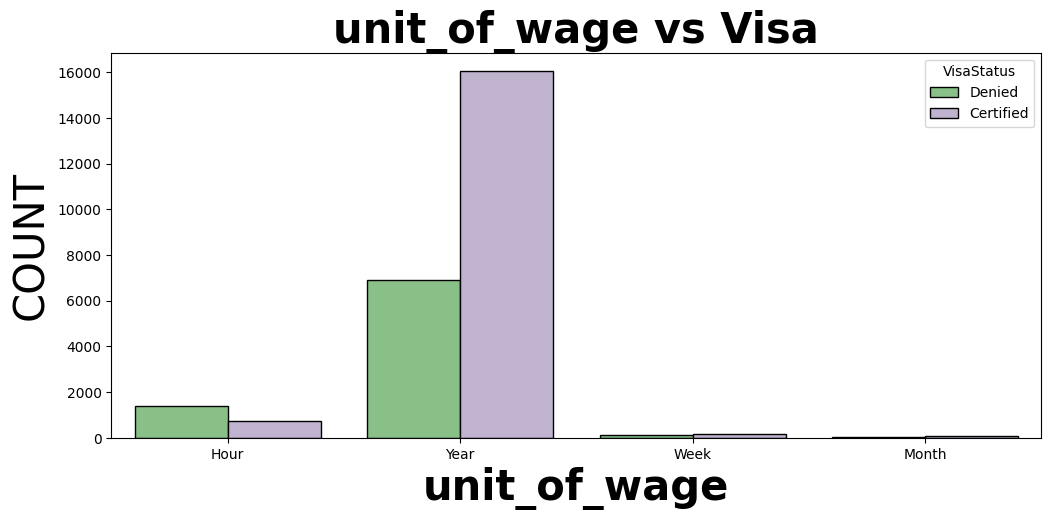

In [39]:
plt.figure(figsize=(12,5))
sns.countplot(x="unit_of_wage",hue="case_status",ec="black",data=data,palette="Accent")
plt.title("unit_of_wage vs Visa",weight="bold",fontsize=30)
plt.xlabel("unit_of_wage",weight="bold",fontsize=30)
plt.ylabel("COUNT",fontsize=30)
plt.legend(title="VisaStatus",fancybox=True)
plt.show()

In [40]:
# full_time_position
data.groupby("full_time_position")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
full_time_position case_status            
N                  Certified     68.526044
                   Denied        31.473956
Y                  Certified     66.583235
                   Denied        33.416765

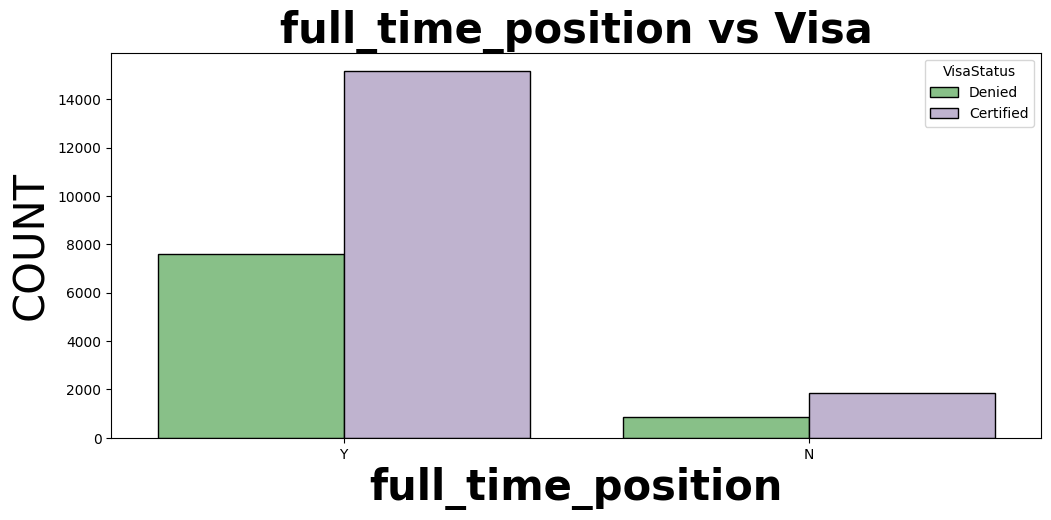

In [41]:
plt.figure(figsize=(12,5))
sns.countplot(x="full_time_position",hue="case_status",ec="black",data=data,palette="Accent")
plt.title("full_time_position vs Visa",weight="bold",fontsize=30)
plt.xlabel("full_time_position",weight="bold",fontsize=30)
plt.ylabel("COUNT",fontsize=30)
plt.legend(title="VisaStatus",fancybox=True)
plt.show()

In [42]:
# Data cleaning
import numpy as np

In [43]:
# Checking Nan values

feature_nan = [ column for column in data.columns if data[column].isnull().sum()>=1]

if len(feature_nan)==0:

    print("Datset Has no nan values")

else:

    for feature in feature_nan:

        print(f"{feature} has {np.round(data[feature].isnull().mean()*100,4)} Nulls")


Datset Has no nan values


In [44]:
np.round(90.345098673,5)

90.3451

In [45]:
# Rmove case id
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [46]:
data.drop(columns=["case_id"],axis=1,inplace=True)

In [47]:
data.head(1)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied


In [48]:
# year of etablishment column has years data ,it just showing year as humans we understand age of comapny in years 
# so i am creating new clumn (Age_of_company)

import datetime

In [49]:
current_year = datetime.datetime.now().year

data["Age_of_Company"] = current_year-data["yr_of_estab"]

In [50]:
data["Age_of_Company"]

0         19
1         24
2         18
3        129
4         21
        ... 
25475     18
25476     20
25477    116
25478    139
25479     66
Name: Age_of_Company, Length: 25480, dtype: int64

In [51]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,Age_of_Company
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [52]:
data.drop("yr_of_estab",axis=1,inplace=True)

In [53]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [54]:
two_categories  = []
more_categories = []

for column in categorical_features:

    if len(data[column].unique())==2:

        two_categories.append(column)

    else:
      
      more_categories.append(column)
    
    print(f"{column} has {len(data[column].unique())} categories")
    print()



continent has 6 categories

education_of_employee has 4 categories

has_job_experience has 2 categories

requires_job_training has 2 categories

region_of_employment has 5 categories

unit_of_wage has 4 categories

full_time_position has 2 categories

case_status has 2 categories



In [55]:
two_categories

['has_job_experience',
 'requires_job_training',
 'full_time_position',
 'case_status']

In [56]:
more_categories

['continent', 'education_of_employee', 'region_of_employment', 'unit_of_wage']

In [57]:
x = data.drop("case_status",axis=1)
y=data["case_status"]

In [58]:
x.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,Age_of_Company
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,21


In [59]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [60]:
y = np.where(y=="Certified",1,0)

In [61]:
y 

array([0, 1, 0, ..., 1, 1, 1])

In [ ]:
# from sklearn.model_selection import train_test_split

# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [63]:
x_train

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,Age_of_Company
5244,Asia,Master's,Y,N,2076,Northeast,100556.2500,Year,Y,26
10841,Asia,Bachelor's,N,Y,2485,South,129987.3500,Year,Y,14
22027,South America,Doctorate,N,N,2331,Northeast,846.9589,Hour,Y,131
22643,Europe,Master's,N,N,1288,South,106195.7600,Year,N,21
4914,Asia,Doctorate,N,N,4767,Island,96986.5500,Year,Y,54
...,...,...,...,...,...,...,...,...,...,...
21575,North America,Master's,Y,N,4196,Midwest,110878.3800,Year,N,16
5390,Asia,Master's,Y,N,1915,West,86111.1300,Year,Y,13
860,Europe,Master's,N,N,2922,West,96192.5800,Year,Y,25
15795,Asia,Master's,Y,N,6155,Northeast,98659.0100,Year,Y,15


In [64]:
x_test

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,Age_of_Company
16745,Asia,Doctorate,Y,N,1337,South,199777.5900,Year,Y,37
9526,Asia,Master's,Y,N,1212,West,69370.5800,Year,Y,117
8358,Asia,Bachelor's,Y,N,2253,West,60749.3400,Year,Y,36
18347,Asia,Bachelor's,N,Y,14083,West,70048.7300,Year,Y,112
2173,Asia,Bachelor's,Y,N,2940,Northeast,127180.6700,Year,Y,186
...,...,...,...,...,...,...,...,...,...,...
16171,Oceania,Master's,N,N,5491,Midwest,26730.6300,Year,N,121
11000,Asia,Master's,Y,N,2162,South,43592.5600,Year,Y,42
7051,Asia,Master's,N,N,422,South,459.6712,Hour,Y,15
13398,Asia,Master's,Y,N,46126,South,29170.2200,Year,Y,20


In [65]:
y_test.shape

(6370,)

In [66]:
numerical_features.append("Age_of_Company")
numerical_features.remove("yr_of_estab")

In [67]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder

In [69]:
# Numerical columns pipeline

numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [70]:
# binary categorical pipeline
binary_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("scaler",OrdinalEncoder())
])

In [121]:
# multi categorical pipeline
multi_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("scaler",OneHotEncoder(handle_unknown="ignore"))
])

In [122]:
preprocessing= ColumnTransformer([
    ("num",numerical_pipeline,numerical_features),
    ("binary",binary_pipeline,two_categories),
    ("multi",multi_pipeline,more_categories)

])

In [73]:
preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['no_of_employees', 'prevailing_wage',
                                  'Age_of_Company']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler', OrdinalEncoder())]),
                                 ['has_job_experience', 'requires_job_training',
                                  'full_time_position', 'case_status']),
                                ('multi',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frquent')),
                                                 ('scaler',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['continent', 'education_of_employee',
                                  'region_of_employment', 'unit_of_wage'])])

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# models = {
#     "Logistic_regression":LogisticRegression(),
#     "svc":SVC(),
#     "Decision_Tree":DecisionTreeClassifier()

# }

In [ ]:
# for key ,value in models.items():

#     training_pipeline =  Pipeline([

#         ("preprocessing",preprocessing),

#         (key,value)])
    
#     training_pipeline.fit(x_train,y_train)
    
#     print (f"{key} Training Score " )

#     print(training_pipeline.score(x_train,y_train))
    
#     y_pred = training_pipeline.predict(x_test)

#     score = accuracy_score(y_test,y_pred)

#     print(f"{key} accuracy score is {score}")


#     print()


Logistic_regression Training Score 
0.7371533228676086
Logistic_regression accuracy score is 0.7419152276295133

svc Training Score 
0.7558869701726845
svc accuracy score is 0.7519623233908949

Decision_Tree Training Score 
1.0
Decision_Tree accuracy score is 0.6671899529042387



In [129]:
# class imbalance 
data["case_status"].value_counts(normalize=True)*100

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64

In [132]:
def evaluate(actual,predict):

    accuracy = accuracy_score(actual,predict)

    confusion = confusion_matrix(actual,predict)

    precision = precision_score(actual,predict)

    f1 = f1_score(actual,predict)

    recall = recall_score(actual,predict)

    return accuracy,confusion,precision,f1,recall

In [152]:
models = {
    "Logistic_regression":LogisticRegression(),
    "svc":SVC(),
    "Decision_Tree":DecisionTreeClassifier(),
    "Random_forest":RandomForestClassifier()

}
print(len(models))

4


In [166]:
# Evaluate models

def evaluate_model(x,y,models):

    # separate dataset into train and test

    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42,shuffle=True)

    models_list = []

    accuracy_list_train = []

    accuracy_list_test = []

    for i in range(len(models)):

        model = list(models.values())[i]
        
        training_pipeline =  Pipeline([

           ("preprocessing",preprocessing),

            ("model",model)])
        

        training_pipeline.fit(x_train,y_train)

        # making predictions 

        y_train_pred = training_pipeline.predict(x_train)
        y_test_pred = training_pipeline.predict(x_test)

        # training set performances

        model_train_accuracy,modle_train_confusion,model_train_precision,\
        model_train_f1,model_train_recall=evaluate(y_train,y_train_pred)


        # test set performances
        
        model_test_accuracy,modle_test_confusion,model_test_precision,\
        model_test_f1,model_test_recall=evaluate(y_test,y_test_pred) 

        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print("model performance for training Data ")
        print("- Accuracy {:.4f}".format(model_train_accuracy))
        accuracy_list_train.append(model_train_accuracy)
        print("- Confusion_matrix".format(modle_train_confusion))
        print("- precision{:.4f}".format(model_train_precision))
        print("- f1 {:.4f}".format(model_train_f1))
        print("- Recall{:.4f}".format(model_train_recall))

        print("----------------------------")


        print("model performance for test Data ")
        print("- Accuracy {:.4f}".format(model_test_accuracy))
        accuracy_list_test.append(model_test_accuracy)
        print("- Confusion_matrix".format(modle_test_confusion))
        print("- precision{:.4f}".format(model_test_precision))
        print("- f1 {:.4f}".format(model_test_f1))
        print("- Recall{:.4f}".format(model_test_recall))


    report = pd.DataFrame(list(zip(models_list,accuracy_list_test,accuracy_list_train)),columns=["Model","Test_Accuracy","Train_Accuracy"])

    return report 

    

In [167]:
evaluating_model = evaluate_model(x,y,models)

Logistic_regression
model performance for training Data 
- Accuracy 0.7372
- Confusion_matrix
- precision0.7648
- f1 0.8164
- Recall0.8756
----------------------------
model performance for test Data 
- Accuracy 0.7419
- Confusion_matrix
- precision0.7648
- f1 0.8213
- Recall0.8869
svc
model performance for training Data 
- Accuracy 0.7559
- Confusion_matrix
- precision0.7852
- f1 0.8269
- Recall0.8732
----------------------------
model performance for test Data 
- Accuracy 0.7520
- Confusion_matrix
- precision0.7790
- f1 0.8257
- Recall0.8784
Decision_Tree
model performance for training Data 
- Accuracy 1.0000
- Confusion_matrix
- precision1.0000
- f1 1.0000
- Recall1.0000
----------------------------
model performance for test Data 
- Accuracy 0.6662
- Confusion_matrix
- precision0.7558
- f1 0.7479
- Recall0.7402
Random_forest
model performance for training Data 
- Accuracy 1.0000
- Confusion_matrix
- precision1.0000
- f1 1.0000
- Recall1.0000
----------------------------
model perfo

In [168]:
evaluating_model

,Model,Test_Accuracy,Train_Accuracy
0,Logistic_regression,0.741915,0.737153
1,svc,0.751962,0.755887
2,Decision_Tree,0.666248,1.000000
3,Random_forest,0.727630,1.000000
